In [50]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [51]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from keras.optimizers import Adam, SGD
from src.utils import plot_history
from src.train_ann_model import train_model
from keras.optimizers.schedules import ExponentialDecay
from keras.callbacks import LearningRateScheduler



In [52]:
df_train = pd.read_csv('../data/fashion-mnist_train.csv')
df_test = pd.read_csv('../data/fashion-mnist_test.csv')

In [53]:
scaler = MinMaxScaler()
labels = df_train.pop('label')
inputs = scaler.fit_transform(df_train.values)

In [54]:
y_test = df_test.pop('label')
x_test = scaler.fit_transform(df_test)

In [55]:
def step_decay(epoch):
    initial_lr = 0.1
    drop = 0.5
    epochs_drop = 5

    lr =  initial_lr * (drop ** (epoch // epochs_drop))
    print(f"Epoch {epoch+1}: lr={lr:.6f}")
    return lr

step_scheduler = LearningRateScheduler(step_decay)

In [57]:
model, history, times = train_model(
    inputs,
    labels,
    optimiser=SGD(),
    learning_rate_scheduler=step_scheduler,
    epochs=20,
    batch_size=128
)

Run script with 'sudo' on Mac/Linux to force higher CPU priority.


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,554 (955.29 KB)

 Trainable params: 243,658 (951.79 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1: lr=0.100000
Epoch 2: lr=0.100000
Epoch 3: lr=0.100000
Epoch 4: lr=0.100000
Epoch 5: lr=0.100000
Epoch 6: lr=0.050000
Epoch 7: lr=0.050000
Epoch 8: lr=0.050000
Epoch 9: lr=0.050000
Epoch 10: lr=0.050000
Epoch 11: lr=0.025000
Epoch 12: lr=0.025000
Epoch 13: lr=0.025000
Epoch 14: lr=0.025000
Epoch 15: lr=0.025000
Epoch 16: lr=0.012500
Epoch 17: lr=0.012500
Epoch 18: lr=0.012500
Epoch 19: lr=0.012500
Epoch 20: lr=0.012500


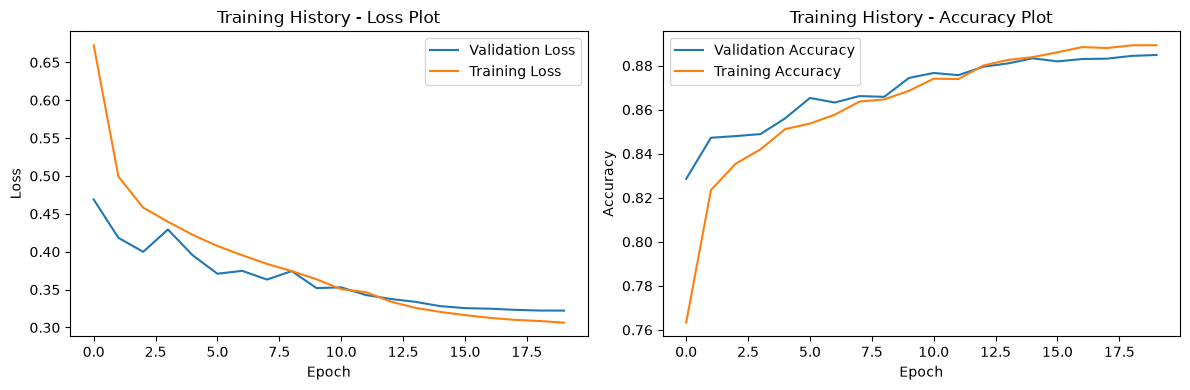

In [60]:
plot_history(history)

In [61]:
lr_schedule = ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=1000,
    decay_rate=0.96,
    staircase=False
)

optimizer = Adam(learning_rate=lr_schedule)


In [62]:
model, history, times = train_model(
    inputs,
    labels,
    optimiser=optimizer,
    epochs=20,
    batch_size=128
)

Run script with 'sudo' on Mac/Linux to force higher CPU priority.


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,554 (955.29 KB)

 Trainable params: 243,658 (951.79 KB)

 Non-trainable params: 896 (3.50 KB)

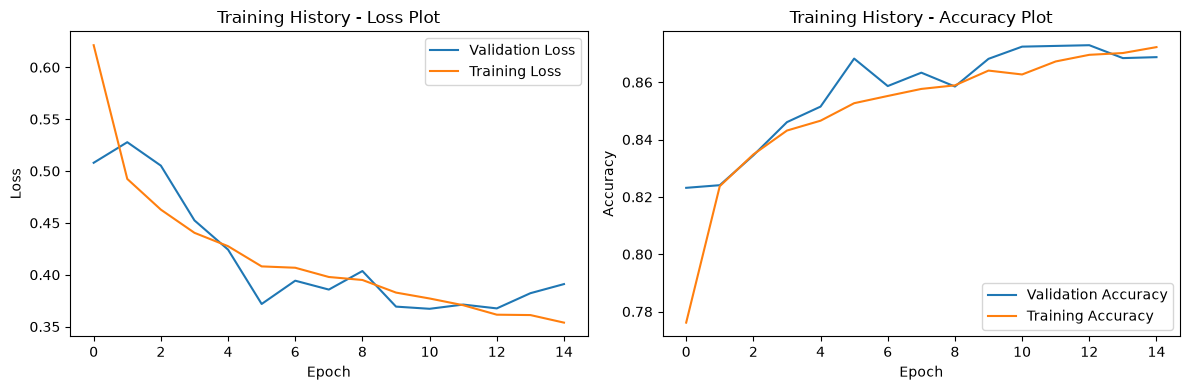

In [63]:
plot_history(history)

In [64]:
def cosine_decay(epoch):
    initial_lr = 0.1
    min_lr = 0.0001
    total_epochs = 20

    lr = min_lr + 0.5 * (initial_lr - min_lr) * (
        1 + np.cos(np.pi * epoch / total_epochs)
    )

    print(f"Epoch {epoch+1}: lr={lr:.6f}")

    return lr

cosine_scheduler = LearningRateScheduler(cosine_decay)

In [65]:
model, history, times = train_model(
    inputs,
    labels,
    optimiser=SGD(),
    learning_rate_scheduler=cosine_scheduler,
    epochs=20,
    batch_size=128
)

Run script with 'sudo' on Mac/Linux to force higher CPU priority.


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,554 (955.29 KB)

 Trainable params: 243,658 (951.79 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1: lr=0.100000
Epoch 2: lr=0.099385
Epoch 3: lr=0.097555
Epoch 4: lr=0.094556
Epoch 5: lr=0.090460
Epoch 6: lr=0.085370
Epoch 7: lr=0.079410
Epoch 8: lr=0.072727
Epoch 9: lr=0.065485
Epoch 10: lr=0.057864
Epoch 11: lr=0.050050
Epoch 12: lr=0.042236
Epoch 13: lr=0.034615
Epoch 14: lr=0.027373
Epoch 15: lr=0.020690
Epoch 16: lr=0.014730
Epoch 17: lr=0.009640
Epoch 18: lr=0.005544
Epoch 19: lr=0.002545
Epoch 20: lr=0.000715


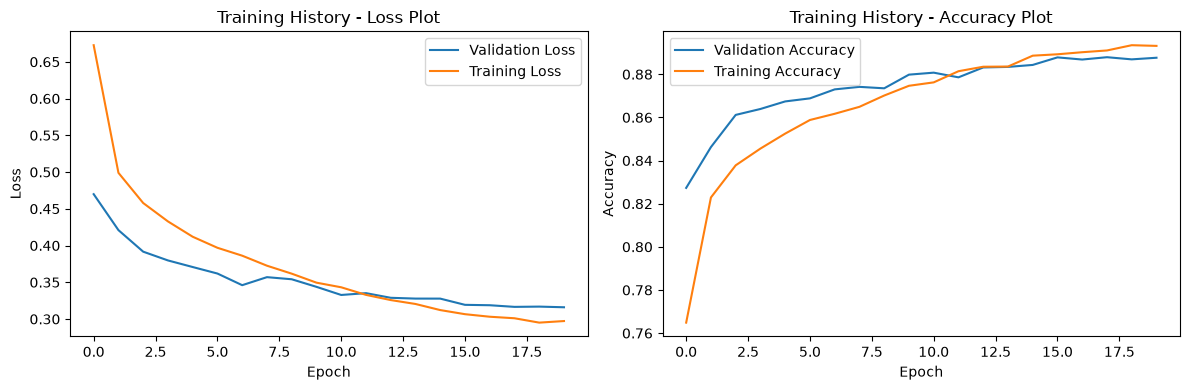

In [66]:
plot_history(history)

# Learning Rate Scheduler Observations

## Step Decay

- Learning rate was reduced at fixed intervals, resulting in stable and predictable convergence.
- Training and validation curves were smooth with minimal oscillations.
- Achieved strong validation accuracy and loss.
- Easy to tune and interpret.

### Observation
Step Decay provided the most straightforward and stable training behavior.

---

## Exponential Decay

- Learning rate decreased continuously throughout training.
- Validation curves showed slightly more fluctuation compared to Step Decay.
- Convergence remained stable and final performance was comparable to Step Decay.
- Allowed larger updates early in training and finer updates later.

### Observation
Exponential Decay offered a smoother transition in learning rate but introduced slightly noisier training dynamics.

---

## Cosine Annealing

- Performance was highly dependent on the initial learning rate.
- With an initial learning rate of 0.01, convergence occurred too early and validation performance was lower.
- Increasing the initial learning rate to 0.1 significantly improved results.
- Produced smooth convergence and strong final validation accuracy.

### Observation
Cosine Annealing was the most sensitive to hyperparameter choice but delivered competitive results when paired with a sufficiently large initial learning rate.

---

## Overall Conclusion

- Learning rate scheduling improved training stability compared to a fixed learning rate.
- Step Decay was the most stable scheduler.
- Exponential Decay provided smooth learning rate transitions with similar performance.
- Cosine Annealing required more careful tuning but showed the best potential when configured appropriately.
- The choice of initial learning rate had a greater impact on performance than the choice of scheduler itself.